# Figure Generation for Milestone 3 Mid-Project Review

This notebook helps generate the three recommended report figures:

1. **Failure timeline** (Section 2.4)  
2. **Threshold curve** (Section 6.2)  
3. **Feature importance plot** (Section 6.4)  

It is designed to work with **saved artifacts** when available, and includes a **feature-importance fallback** using the XGBoost results already documented for the 24h, 48h, and 72h windows.

Update the paths in the configuration cell before running.


## Generate Threshold Sweep and Feature Importance Plots

In [1]:
from __future__ import annotations

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# USER CONFIGURATION
# -----------------------------
# BASE_DIR = Path(".").resolve()
BASE_DIR = Path("..")

# Sample event parquet (already provided in this environment)
# EVENT_PARQUET_PATH = BASE_DIR / "A_event_0.parquet"
EVENT_PARQUET_PATH = BASE_DIR / "data" / "processed" / "A_event_0.parquet"

# Optional saved threshold sweep artifact
# Expected columns: threshold, precision, recall, f1
# THRESHOLD_SWEEP_PATH = BASE_DIR / "threshold_sweep_xgboost_72h.csv"
THRESHOLD_SWEEP_PATH = BASE_DIR / "artifacts" / "modeling" / "pre_72h" / "pre_72h_20260321_144937" / "threshold_sweep.csv"

# Optional saved feature importance artifact
# Expected columns: feature, importance
# FEATURE_IMPORTANCE_PATH = BASE_DIR / "feature_importance_xgboost_72h.csv"
FEATURE_IMPORTANCE_PATH = BASE_DIR / "artifacts" / "modeling" / "pre_72h" / "pre_72h_20260321_144937" / "feature_importance.csv"

# Output directories
FIG_DIR = BASE_DIR / "outputs"
TIMELINE_DIR = FIG_DIR / "failure_timelines"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TIMELINE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {BASE_DIR}")
print(f"Figures will be written to: {FIG_DIR}")


Working directory: ..
Figures will be written to: ../outputs


## 1. Generate failure timeline candidates

This section loops through all events in the parquet file and saves a normalized timeline plot for each one.  
You can then scan the output folder and choose the best figure for the report.


In [2]:
# ------------------------------------------------------------
# Load event parquet
# ------------------------------------------------------------
df_event = pd.read_parquet(EVENT_PARQUET_PATH)

# Column names based on the provided sample parquet
timestamp_col = "time_stamp"
farm_col = "farm_id"
turbine_col = "asset_id"
event_id_col = "event_id"
event_label_col = "event_label"
event_start_col = "event_start"
event_end_col = "event_end"

# Signals chosen for interpretability rather than raw importance rank alone
signal_cols = [
    "vibration_raw",
    "nacelle_temp",
    "temp_delta_gearbox",
]

# Window around event start
hours_before = 168  # 7 days
hours_after = 24    # 1 day

# Parse datetimes
df_event[timestamp_col] = pd.to_datetime(df_event[timestamp_col], errors="coerce")
df_event[event_start_col] = pd.to_datetime(df_event[event_start_col], errors="coerce")
df_event[event_end_col] = pd.to_datetime(df_event[event_end_col], errors="coerce")

df_event = df_event.sort_values([farm_col, turbine_col, timestamp_col]).reset_index(drop=True)

event_index_df = (
    df_event[
        [farm_col, turbine_col, event_id_col, event_label_col, event_start_col, event_end_col]
    ]
    .dropna(subset=[event_start_col])
    .drop_duplicates()
    .sort_values([farm_col, turbine_col, event_start_col, event_id_col])
    .reset_index(drop=True)
)

print(f"Rows in event parquet: {len(df_event):,}")
print(f"Unique turbine/event combinations: {len(event_index_df):,}")
event_index_df.head()


Rows in event parquet: 54,986
Unique turbine/event combinations: 1


,farm_id,asset_id,event_id,event_label,event_start,event_end
0,A,0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00


In [3]:
def make_failure_timeline_plot(
    df_all: pd.DataFrame,
    farm_id,
    turbine_id,
    event_id,
    event_label,
    event_start: pd.Timestamp,
    signal_cols: list[str],
    output_path: Path,
    hours_before: int = 168,
    hours_after: int = 24,
    dpi: int = 300,
) -> None:
    df_turbine = df_all[
        (df_all[farm_col] == farm_id) &
        (df_all[turbine_col] == turbine_id)
    ].copy()

    window_start = event_start - pd.Timedelta(hours=hours_before)
    window_end = event_start + pd.Timedelta(hours=hours_after)

    df_window = df_turbine[
        (df_turbine[timestamp_col] >= window_start) &
        (df_turbine[timestamp_col] <= window_end)
    ].copy()

    if df_window.empty:
        return

    df_window["hours_from_event_start"] = (
        (df_window[timestamp_col] - event_start).dt.total_seconds() / 3600.0
    )

    normalized_cols = []
    for col in signal_cols:
        series = pd.to_numeric(df_window[col], errors="coerce")
        std = series.std()
        if pd.isna(std) or std == 0:
            df_window[f"{col}_z"] = 0.0
        else:
            df_window[f"{col}_z"] = (series - series.mean()) / std
        normalized_cols.append(f"{col}_z")

    fig, ax = plt.subplots(figsize=(10, 5.5))

    for original_col, norm_col in zip(signal_cols, normalized_cols):
        ax.plot(
            df_window["hours_from_event_start"],
            df_window[norm_col],
            linewidth=2,
            label=original_col.replace("_", " ").title(),
        )

    ax.axvline(0, linestyle="--", linewidth=2, label="Event Start")
    ax.set_title(
        f"Farm {farm_id} | Turbine {turbine_id} | Event {event_id} ({event_label})",
        fontsize=12,
        pad=12,
    )
    ax.set_xlabel("Hours Relative to Event Start", fontsize=10)
    ax.set_ylabel("Normalized Sensor Value (z-score)", fontsize=10)
    ax.set_xlim(-hours_before, hours_after)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)


In [4]:
# Generate and index all candidate timeline plots
saved_records = []

for row in event_index_df.itertuples(index=False):
    farm_id = getattr(row, farm_col)
    turbine_id = getattr(row, turbine_col)
    event_id = getattr(row, event_id_col)
    event_label = getattr(row, event_label_col)
    event_start = getattr(row, event_start_col)
    event_end = getattr(row, event_end_col)

    safe_label = str(event_label).replace(" ", "_").replace("/", "_")
    file_name = f"farm_{farm_id}_turbine_{turbine_id}_event_{event_id}_{safe_label}.png"
    output_path = TIMELINE_DIR / file_name

    make_failure_timeline_plot(
        df_all=df_event,
        farm_id=farm_id,
        turbine_id=turbine_id,
        event_id=event_id,
        event_label=event_label,
        event_start=event_start,
        signal_cols=signal_cols,
        output_path=output_path,
        hours_before=hours_before,
        hours_after=hours_after,
    )

    saved_records.append(
        {
            "farm_id": farm_id,
            "asset_id": turbine_id,
            "event_id": event_id,
            "event_label": event_label,
            "event_start": event_start,
            "event_end": event_end,
            "file_name": file_name,
            "file_path": str(output_path),
        }
    )

timeline_index_df = pd.DataFrame(saved_records)
timeline_index_path = TIMELINE_DIR / "failure_timeline_index.csv"
timeline_index_df.to_csv(timeline_index_path, index=False)

print(f"Saved {len(timeline_index_df)} timeline plots.")
print(f"Index CSV: {timeline_index_path}")
timeline_index_df.head()


Saved 1 timeline plots.
Index CSV: ../outputs/failure_timelines/failure_timeline_index.csv


,farm_id,asset_id,event_id,event_label,event_start,event_end,file_name,file_path
0,A,0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,farm_A_turbine_0_event_0_anomaly.png,../outputs/failure_timelines/farm_A_turbine_0_...


## 2. Generate threshold curve

This expects a saved threshold sweep artifact with columns:

- `threshold`
- `precision`
- `recall`
- `f1`

Recommended figure for the report: **XGBoost, 72h window**


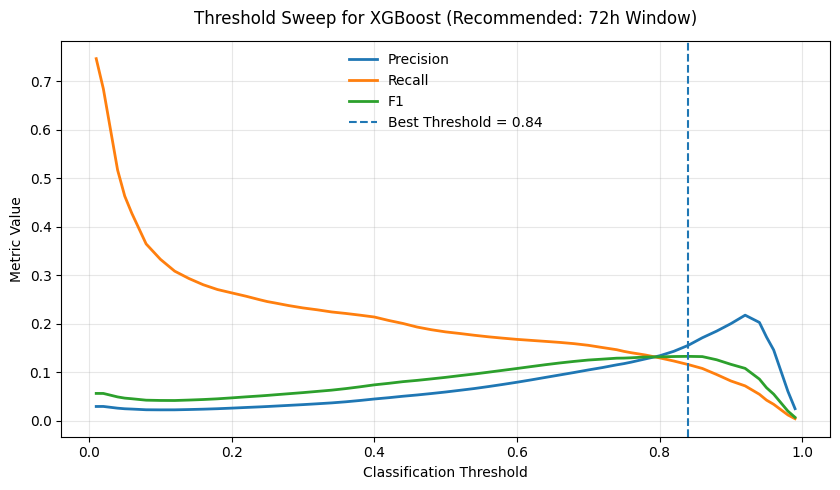

Saved threshold figure to: ../outputs/threshold_curve_xgboost_72h.png
Best threshold = 0.840, Best F1 = 0.132


In [7]:
if THRESHOLD_SWEEP_PATH.exists():
    threshold_df = (
        pd.read_parquet(THRESHOLD_SWEEP_PATH)
        if THRESHOLD_SWEEP_PATH.suffix.lower() == ".parquet"
        else pd.read_csv(THRESHOLD_SWEEP_PATH)
    )

    required_cols = {"threshold", "precision", "recall", "f1"}
    missing = required_cols - set(threshold_df.columns)
    if missing:
        raise KeyError(f"Threshold sweep artifact is missing columns: {missing}")

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"], linewidth=2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"], linewidth=2, label="F1")

    best_idx = threshold_df["f1"].idxmax()
    best_threshold = threshold_df.loc[best_idx, "threshold"]
    best_f1 = threshold_df.loc[best_idx, "f1"]

    ax.axvline(best_threshold, linestyle="--", linewidth=1.5, label=f"Best Threshold = {best_threshold:.2f}")
    ax.set_title("Threshold Sweep for XGBoost (Recommended: 72h Window)", fontsize=12, pad=12)
    ax.set_xlabel("Classification Threshold", fontsize=10)
    ax.set_ylabel("Metric Value", fontsize=10)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    threshold_fig_path = FIG_DIR / "threshold_curve_xgboost_72h.png"
    fig.savefig(threshold_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved threshold figure to: {threshold_fig_path}")
    print(f"Best threshold = {best_threshold:.3f}, Best F1 = {best_f1:.3f}")
else:
    print(
        "Threshold sweep artifact not found.\n"
        "Update THRESHOLD_SWEEP_PATH to your saved sweep CSV/parquet file."
    )


## 3. Generate feature importance plot

Recommended figure for the report: **XGBoost, 72h window**

This section first tries to load a saved artifact.  
If none is found, it falls back to the feature importance values already recorded for the 24h, 48h, and 72h experiments.


In [5]:
# Embedded fallback feature importance values from the documented experiments
feature_importance_fallback = {
    "24h": [
        ("vibration_raw", 0.087857),
        ("vibration_magnitude", 0.083750),
        ("nacelle_temp", 0.080832),
        ("wind_speed", 0.075163),
        ("amb_temp", 0.059163),
        ("power_efficiency", 0.057438),
        ("temp_delta_gearbox", 0.051353),
        ("hydraulic_temp", 0.046685),
        ("generator_temp", 0.040947),
        ("temp_divergence", 0.040334),
        ("hub_temp", 0.036815),
        ("active_power_volatility_24", 0.035050),
        ("gearbox_oil_temp", 0.033363),
        ("yaw_error_volatility_6", 0.031758),
        ("transformer_temp", 0.025902),
        ("yaw_error_volatility_24", 0.021703),
        ("yaw_error", 0.020713),
        ("pitch_angle", 0.020496),
        ("active_power", 0.020306),
        ("gen_speed", 0.019048),
    ],
    "48h": [
        ("vibration_magnitude", 0.083620),
        ("vibration_raw", 0.080383),
        ("wind_speed", 0.075960),
        ("nacelle_temp", 0.072551),
        ("amb_temp", 0.058231),
        ("power_efficiency", 0.055059),
        ("hydraulic_temp", 0.051339),
        ("temp_delta_gearbox", 0.044454),
        ("temp_divergence", 0.043786),
        ("generator_temp", 0.040375),
        ("active_power_volatility_24", 0.039771),
        ("hub_temp", 0.035648),
        ("gearbox_oil_temp", 0.034417),
        ("yaw_error_volatility_6", 0.033285),
        ("transformer_temp", 0.026691),
        ("yaw_error", 0.024098),
        ("yaw_error_volatility_24", 0.023358),
        ("pitch_angle", 0.021661),
        ("active_power", 0.020142),
        ("gen_speed", 0.019615),
    ],
    "72h": [
        ("vibration_magnitude", 0.086311),
        ("vibration_raw", 0.073592),
        ("nacelle_temp", 0.072477),
        ("wind_speed", 0.070306),
        ("power_efficiency", 0.059509),
        ("amb_temp", 0.056916),
        ("temp_delta_gearbox", 0.052876),
        ("hydraulic_temp", 0.050225),
        ("temp_divergence", 0.042816),
        ("yaw_error_volatility_6", 0.040958),
        ("active_power_volatility_24", 0.039414),
        ("generator_temp", 0.038907),
        ("hub_temp", 0.036645),
        ("gearbox_oil_temp", 0.031920),
        ("transformer_temp", 0.027346),
        ("yaw_error_volatility_24", 0.024290),
        ("pitch_angle", 0.023216),
        ("yaw_error", 0.021586),
        ("gen_speed", 0.019665),
        ("active_power", 0.019096),
    ],
}

selected_window = "72h"   # recommended for report
top_n = 20                # recommended: 15 or 20


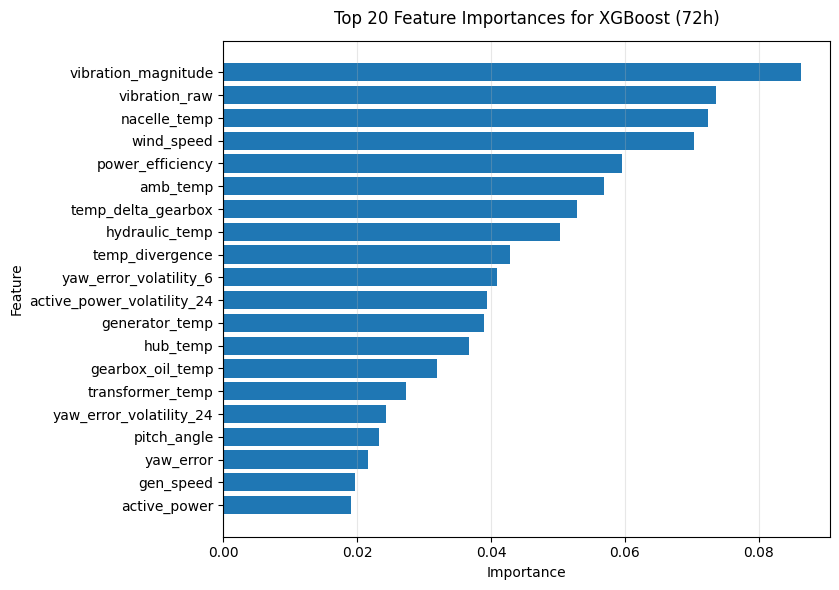

Saved feature importance figure to: ../outputs/feature_importance_xgboost_72h.png


In [6]:
if FEATURE_IMPORTANCE_PATH.exists():
    importance_df = (
        pd.read_parquet(FEATURE_IMPORTANCE_PATH)
        if FEATURE_IMPORTANCE_PATH.suffix.lower() == ".parquet"
        else pd.read_csv(FEATURE_IMPORTANCE_PATH)
    )
    required_cols = {"feature", "importance"}
    missing = required_cols - set(importance_df.columns)
    if missing:
        raise KeyError(f"Feature importance artifact is missing columns: {missing}")
else:
    importance_df = pd.DataFrame(feature_importance_fallback[selected_window], columns=["feature", "importance"])

importance_df = importance_df.sort_values("importance", ascending=True).tail(top_n)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(importance_df["feature"], importance_df["importance"])
ax.set_title(f"Top {top_n} Feature Importances for XGBoost ({selected_window})", fontsize=12, pad=12)
ax.set_xlabel("Importance", fontsize=10)
ax.set_ylabel("Feature", fontsize=10)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()

importance_fig_path = FIG_DIR / f"feature_importance_xgboost_{selected_window}.png"
fig.savefig(importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved feature importance figure to: {importance_fig_path}")


## 4. Recommended report figure set

Given the page limit, the strongest 3-figure combination is:

1. **Failure timeline** from Section 2.4  
2. **Threshold curve** from Section 6.2  
3. **Feature importance plot** from Section 6.4  

Recommended choices:
- Threshold curve: **XGBoost, 72h**
- Feature importance: **XGBoost, 72h**
- Feature importance size: **Top 15–20**


## Generate Prediction Timeline Plots

In [17]:
# ============================================================
# Generate failure timeline plots for every event parquet file
# and every turbine/event inside each file
# ============================================================

from __future__ import annotations

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# USER CONFIG
# ------------------------------------------------------------
# EVENT_PARQUET_DIR = Path("/mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/notebooks")
# PARQUET_GLOB = "*_event_*.parquet"   # adjust if needed

# OUTPUT_DIR = EVENT_PARQUET_DIR / "generated_figures" / "failure_timelines"

BASE_DIR = Path("..")

EVENT_PARQUET_DIR = BASE_DIR / "data" / "processed" 
PARQUET_GLOB = "*_event_*.parquet"   # adjust if needed

FIG_DIR = BASE_DIR / "outputs"
OUTPUT_DIR = FIG_DIR / "failure_timelines"

HOURS_BEFORE = 168
HOURS_AFTER = 24

SIGNAL_COLS = [
    "vibration_raw",
    "nacelle_temp",
    "temp_delta_gearbox",
]

DPI = 300
FIGSIZE = (10, 5.5)


# ------------------------------------------------------------
# COLUMN NAMES
# ------------------------------------------------------------
timestamp_col = "time_stamp"
farm_col = "farm_id"
turbine_col = "asset_id"
event_id_col = "event_id"
event_label_col = "event_label"
event_start_col = "event_start"
event_end_col = "event_end"


# ------------------------------------------------------------
# OUTPUT DIR
# ------------------------------------------------------------
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# PLOT FUNCTION
# ------------------------------------------------------------
def make_failure_timeline_plot(
    df_all: pd.DataFrame,
    farm_id,
    turbine_id,
    event_id,
    event_label,
    event_start: pd.Timestamp,
    signal_cols: list[str],
    output_path: Path,
    hours_before: int = 168,
    hours_after: int = 24,
    figsize: tuple[float, float] = (10, 5.5),
    dpi: int = 300,
) -> bool:
    df_turbine = df_all[
        (df_all[farm_col] == farm_id) &
        (df_all[turbine_col] == turbine_id)
    ].copy()

    if df_turbine.empty:
        return False

    window_start = event_start - pd.Timedelta(hours=hours_before)
    window_end = event_start + pd.Timedelta(hours=hours_after)

    df_window = df_turbine[
        (df_turbine[timestamp_col] >= window_start) &
        (df_turbine[timestamp_col] <= window_end)
    ].copy()

    if df_window.empty:
        return False

    df_window["hours_from_event_start"] = (
        (df_window[timestamp_col] - event_start).dt.total_seconds() / 3600.0
    )

    normalized_cols: list[str] = []
    for col in signal_cols:
        series = pd.to_numeric(df_window[col], errors="coerce")
        std = series.std()
        if pd.isna(std) or std == 0:
            df_window[f"{col}_z"] = 0.0
        else:
            df_window[f"{col}_z"] = (series - series.mean()) / std
        normalized_cols.append(f"{col}_z")

    fig, ax = plt.subplots(figsize=figsize)

    for original_col, norm_col in zip(signal_cols, normalized_cols):
        ax.plot(
            df_window["hours_from_event_start"],
            df_window[norm_col],
            linewidth=2,
            label=original_col.replace("_", " ").title(),
        )

    ax.axvline(0, linestyle="--", linewidth=2, label="Event Start")
    ax.set_title(
        f"Farm {farm_id} | Turbine {turbine_id} | Event {event_id} ({event_label})",
        fontsize=12,
        pad=12,
    )
    ax.set_xlabel("Hours Relative to Event Start", fontsize=10)
    ax.set_ylabel("Normalized Sensor Value (z-score)", fontsize=10)
    ax.set_xlim(-hours_before, hours_after)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    return True


# ------------------------------------------------------------
# FIND ALL PARQUET FILES
# ------------------------------------------------------------
parquet_files = sorted(EVENT_PARQUET_DIR.glob(PARQUET_GLOB))

if not parquet_files:
    raise FileNotFoundError(
        f"No parquet files found in {EVENT_PARQUET_DIR} matching {PARQUET_GLOB!r}"
    )

print(f"Found {len(parquet_files)} parquet files.")
for p in parquet_files[:10]:
    print(" -", p.name)


# ------------------------------------------------------------
# LOOP OVER FILES, THEN EVENTS
# ------------------------------------------------------------
saved_records = []
n_files = 0
n_saved = 0
n_skipped = 0

for parquet_path in parquet_files:
    n_files += 1
    print(f"\nProcessing: {parquet_path.name}")

    df = pd.read_parquet(parquet_path).copy()

    required_cols = [
        timestamp_col,
        farm_col,
        turbine_col,
        event_id_col,
        event_label_col,
        event_start_col,
        event_end_col,
    ] + SIGNAL_COLS

    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f"  Skipping {parquet_path.name} -- missing columns: {missing_cols}")
        continue

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
    df[event_start_col] = pd.to_datetime(df[event_start_col], errors="coerce")
    df[event_end_col] = pd.to_datetime(df[event_end_col], errors="coerce")

    df = df.sort_values([farm_col, turbine_col, timestamp_col]).reset_index(drop=True)

    event_index_df = (
        df[
            [farm_col, turbine_col, event_id_col, event_label_col, event_start_col, event_end_col]
        ]
        .dropna(subset=[event_start_col])
        .drop_duplicates()
        .sort_values([farm_col, turbine_col, event_start_col, event_id_col])
        .reset_index(drop=True)
    )

    print(f"  Unique turbine/event combinations: {len(event_index_df)}")

    for row in event_index_df.itertuples(index=False):
        farm_id = getattr(row, farm_col)
        turbine_id = getattr(row, turbine_col)
        event_id = getattr(row, event_id_col)
        event_label = getattr(row, event_label_col)
        event_start = getattr(row, event_start_col)
        event_end = getattr(row, event_end_col)

        safe_label = str(event_label).replace(" ", "_").replace("/", "_")
        stem = parquet_path.stem

        file_name = (
            f"{stem}__farm_{farm_id}_turbine_{turbine_id}_event_{event_id}_{safe_label}.png"
        )
        output_path = OUTPUT_DIR / file_name

        saved = make_failure_timeline_plot(
            df_all=df,
            farm_id=farm_id,
            turbine_id=turbine_id,
            event_id=event_id,
            event_label=event_label,
            event_start=event_start,
            signal_cols=SIGNAL_COLS,
            output_path=output_path,
            hours_before=HOURS_BEFORE,
            hours_after=HOURS_AFTER,
            figsize=FIGSIZE,
            dpi=DPI,
        )

        if saved:
            n_saved += 1
            saved_records.append(
                {
                    "source_file": parquet_path.name,
                    "farm_id": farm_id,
                    "asset_id": turbine_id,
                    "event_id": event_id,
                    "event_label": event_label,
                    "event_start": event_start,
                    "event_end": event_end,
                    "file_name": file_name,
                    "file_path": str(output_path),
                }
            )
        else:
            n_skipped += 1

print(f"\nProcessed parquet files: {n_files}")
print(f"Saved plots: {n_saved}")
print(f"Skipped plots: {n_skipped}")


# ------------------------------------------------------------
# SAVE INDEX CSV
# ------------------------------------------------------------
index_df = pd.DataFrame(saved_records)
index_csv_path = OUTPUT_DIR / "failure_timeline_index.csv"
index_df.to_csv(index_csv_path, index=False)

print(f"Index CSV saved to: {index_csv_path}")
display(index_df.head())

Found 95 parquet files.
 - A_event_0.parquet
 - A_event_10.parquet
 - A_event_13.parquet
 - A_event_14.parquet
 - A_event_17.parquet
 - A_event_22.parquet
 - A_event_24.parquet
 - A_event_25.parquet
 - A_event_26.parquet
 - A_event_3.parquet

Processing: A_event_0.parquet
  Unique turbine/event combinations: 1

Processing: A_event_10.parquet
  Unique turbine/event combinations: 1

Processing: A_event_13.parquet
  Unique turbine/event combinations: 1

Processing: A_event_14.parquet
  Unique turbine/event combinations: 1

Processing: A_event_17.parquet
  Unique turbine/event combinations: 1

Processing: A_event_22.parquet
  Unique turbine/event combinations: 1

Processing: A_event_24.parquet
  Unique turbine/event combinations: 1

Processing: A_event_25.parquet
  Unique turbine/event combinations: 1

Processing: A_event_26.parquet
  Unique turbine/event combinations: 1

Processing: A_event_3.parquet
  Unique turbine/event combinations: 1

Processing: A_event_38.parquet
  Unique turbine/e

,source_file,farm_id,asset_id,event_id,event_label,event_start,event_end,file_name,file_path
0,A_event_0.parquet,A,0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,A_event_0__farm_A_turbine_0_event_0_anomaly.png,../outputs/failure_timelines/A_event_0__farm_A...
1,A_event_10.parquet,A,10,10,anomaly,2023-10-11 08:40:00,2023-10-18 08:40:00,A_event_10__farm_A_turbine_10_event_10_anomaly...,../outputs/failure_timelines/A_event_10__farm_...
2,A_event_13.parquet,A,21,13,normal,2023-05-03 13:20:00,2023-05-24 10:20:00,A_event_13__farm_A_turbine_21_event_13_normal.png,../outputs/failure_timelines/A_event_13__farm_...
3,A_event_14.parquet,A,13,14,normal,2023-03-05 14:00:00,2023-03-12 18:40:00,A_event_14__farm_A_turbine_13_event_14_normal.png,../outputs/failure_timelines/A_event_14__farm_...
4,A_event_17.parquet,A,10,17,normal,2023-11-02 15:20:00,2023-11-16 00:40:00,A_event_17__farm_A_turbine_10_event_17_normal.png,../outputs/failure_timelines/A_event_17__farm_...


## Generate Prediction Timeline Plots

In [ ]:
# ============================================================
# Generate prediction timeline plots for every turbine failure
# ============================================================

from __future__ import annotations

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# USER CONFIG
# ------------------------------------------------------------
PREDICTIONS_PATH = Path("/mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/notebooks/predictions_xgboost_72h.parquet")
OUTPUT_DIR = Path("/mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/notebooks/generated_figures/prediction_timelines")

BASE_DIR = Path("..")
PREDICTIONS_PATH = BASE_DIR / "artifacts" / 
EVENT_PARQUET_DIR = BASE_DIR / "data" / "processed" 
PARQUET_GLOB = "*_event_*.parquet"   # adjust if needed

FIG_DIR = BASE_DIR / "outputs"
OUTPUT_DIR = FIG_DIR / "failure_timelines"

# Time window around event start
HOURS_BEFORE = 168   # 7 days
HOURS_AFTER = 24     # 1 day

# Plot settings
DPI = 300
FIGSIZE = (10, 5.5)

# Threshold to show on plot (recommended: best XGBoost threshold for chosen window)
CLASSIFICATION_THRESHOLD = 0.78

# -----------------------------
# Column names
# Update these to match your predictions artifact
# -----------------------------
timestamp_col = "time_stamp"
farm_col = "farm_id"
turbine_col = "asset_id"

# Probability column from model predictions
proba_col = "y_proba"     # examples: "y_proba", "pred_proba", "probability"

# Optional columns
target_col = "target"     # true label if available
pred_label_col = None     # e.g., "y_pred" if you already saved hard predictions

# Event metadata
event_id_col = "event_id"
event_label_col = "event_label"
event_start_col = "event_start"
event_end_col = "event_end"


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(f"Predictions file not found: {PREDICTIONS_PATH}")

if PREDICTIONS_PATH.suffix.lower() == ".parquet":
    df = pd.read_parquet(PREDICTIONS_PATH).copy()
else:
    df = pd.read_csv(PREDICTIONS_PATH).copy()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_cols = [timestamp_col, farm_col, turbine_col, proba_col]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

for optional_dt_col in [event_start_col, event_end_col]:
    if optional_dt_col in df.columns:
        df[optional_dt_col] = pd.to_datetime(df[optional_dt_col], errors="coerce")

df = df.sort_values([farm_col, turbine_col, timestamp_col]).reset_index(drop=True)

print(f"Loaded rows: {len(df):,}")
print("Columns:", df.columns.tolist())